# 2. Hypothesis Testing: Structural Causality Analysis

**Building on EDA findings:** The EDA established that the raw correlation between paper counts and ETF price (r ≈ 0.49) is spurious — driven by shared long-run trends, not genuine co-movement. After removing trends, the stationary correlation collapsed to r ≈ −0.02.

This raises a more nuanced question: even if there is no *linear* day-to-day relationship, does past arXiv publication volume contain *any* statistically significant information about future ETF movements? This is what Granger causality tests.

### Research Hypotheses

**Hypothesis A — Papers → Market**
- H₀: Past AI paper volumes do **not** Granger-cause BOTZ returns.
- H₁: Past AI paper volumes **do** Granger-cause BOTZ returns.

**Hypothesis B — Market → Papers**
- H₀: Past BOTZ returns do **not** Granger-cause AI paper volumes.
- H₁: Past BOTZ returns **do** Granger-cause AI paper volumes.

### Pipeline
```
Load data  →  Stationarity check (ADF)  →  Granger causality  →  Lag selection  →  Robustness checks  →  Conclusions
```

> **Reminder — Granger causality is not true causality.** The test answers: *does knowing the history of X improve our forecast of Y beyond knowing Y's own history?* A significant result means predictive precedence, not mechanism.

## 0. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

C_ETF   = '#1f77b4'
C_PAPER = '#ff7f0e'
C_SIG   = '#2ca02c'
C_INSIG = '#d62728'
ALPHA   = 0.05

print('Setup complete.')

Setup complete.


## 2.1 Data Loading & Transformation

Granger causality requires **stationary** series. We apply:
- BOTZ price → **percentage return** (removes price trend)
- Paper count → **log-difference** `Δlog(1+count)` (stabilises variance and removes count trend)

Using log-difference instead of raw difference is important here: paper counts grow exponentially over the period, so raw differences would have growing variance (heteroscedasticity), which violates the OLS assumptions underlying the Granger F-test.

In [2]:
df_raw = pd.read_csv('ai_market_master_dataset.csv', parse_dates=['date']).set_index('date')

df = df_raw.copy()
df['price_return']   = df['price'].pct_change()
df['log_paper_diff'] = np.log1p(df['paper_count']).diff()

df_clean = df[['price_return', 'log_paper_diff']].dropna()

print(f'Clean observations : {len(df_clean):,}')
print(f'Date range         : {df_clean.index.min().date()} → {df_clean.index.max().date()}')
print()
print(df_clean.describe().round(6))

Clean observations : 1,835
Date range         : 2016-09-15 → 2023-12-29

       price_return  log_paper_diff
count   1835.000000     1835.000000
mean       0.000510        0.001116
std        0.016303        0.595230
min       -0.124058       -2.140066
25%       -0.007104       -0.382992
50%        0.000934       -0.054067
75%        0.009529        0.405465
max        0.127708        2.036882


## 2.2 Stationarity Testing — Augmented Dickey-Fuller

The ADF test checks for a **unit root** (the statistical definition of a non-stationary series). We run it on both transformed variables.

**Decision rule:** if p < 0.05, reject H₀ (unit root), confirming stationarity.

We also visualise three diagnostic signals that a trained eye looks for:
1. **Rolling mean** — should be flat and near zero for a stationary series.
2. **Rolling std dev** — should be roughly constant (no volatility trends).
3. **ACF / PACF** — autocorrelations should decay quickly to zero.

In [3]:
def run_adf(series: pd.Series, name: str) -> dict:
    """Run ADF test and return a result dict."""
    result = adfuller(series, autolag='AIC')
    return {
        'name'       : name,
        'adf_stat'   : result[0],
        'p_value'    : result[1],
        'lags_used'  : result[2],
        'n_obs'      : result[3],
        'crit_1pct'  : result[4]['1%'],
        'crit_5pct'  : result[4]['5%'],
        'stationary' : result[1] < ALPHA,
    }

results = [
    run_adf(df_clean['price_return'],   'BOTZ Daily Return'),
    run_adf(df_clean['log_paper_diff'], 'AI Papers (log-diff)'),
]

print('ADF TEST RESULTS')
print('═' * 65)
for r in results:
    status = '✓ STATIONARY' if r['stationary'] else '✗ NON-STATIONARY'
    print(f"{r['name']:<30}")
    print(f"  ADF statistic : {r['adf_stat']:>10.4f}   (1% crit: {r['crit_1pct']:.4f}, 5% crit: {r['crit_5pct']:.4f})")
    print(f"  p-value       : {r['p_value']:>10.6f}   Lags used (AIC): {r['lags_used']}")
    print(f"  Result        : {status}")
    print()

ADF TEST RESULTS
═════════════════════════════════════════════════════════════════
BOTZ Daily Return             
  ADF statistic :   -13.6451   (1% crit: -3.4339, 5% crit: -2.8631)
  p-value       :   0.000000   Lags used (AIC): 8
  Result        : ✓ STATIONARY

AI Papers (log-diff)          
  ADF statistic :   -12.5246   (1% crit: -3.4340, 5% crit: -2.8631)
  p-value       :   0.000000   Lags used (AIC): 22
  Result        : ✓ STATIONARY



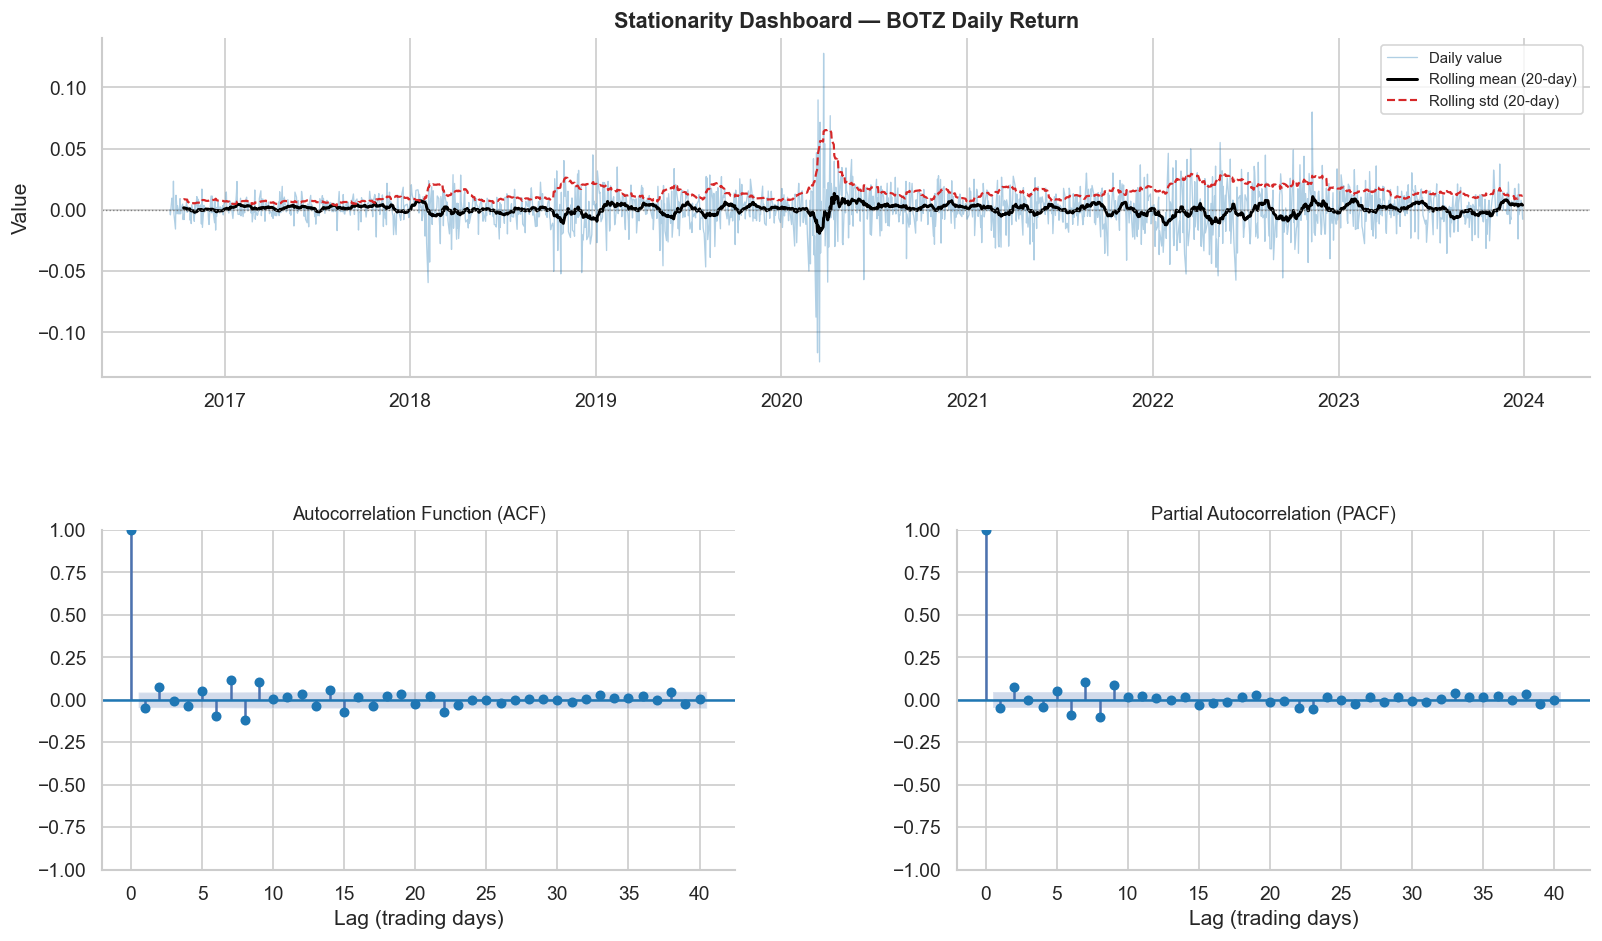

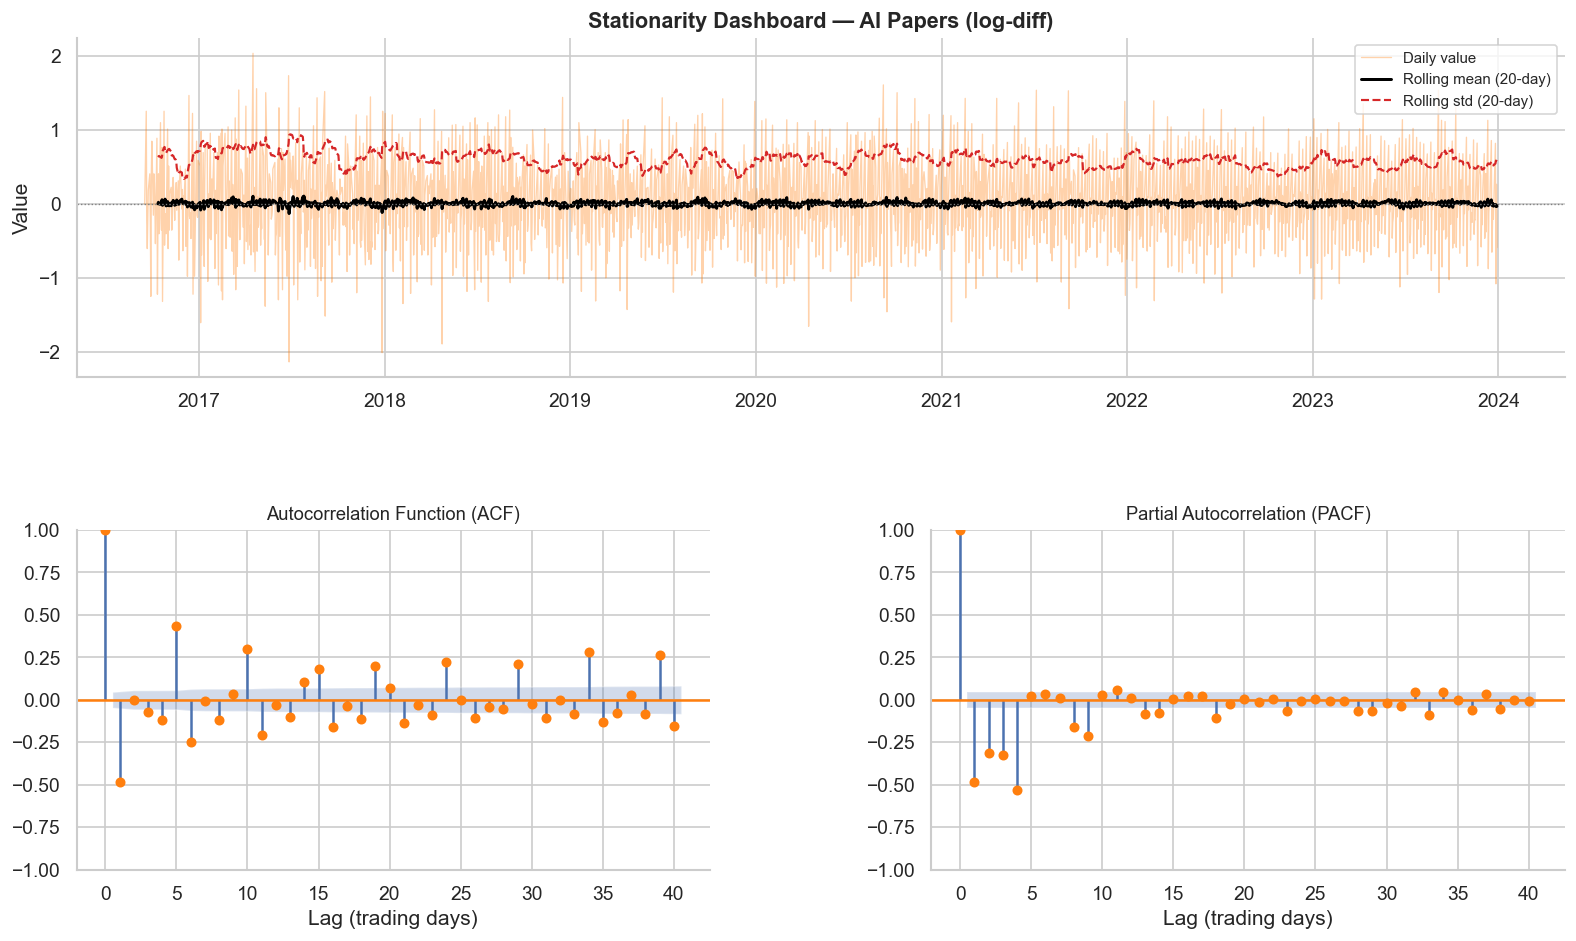


HOW TO READ THE DASHBOARD
──────────────────────────
• Rolling mean (black): A stationary series has a flat mean near zero.
  If it drifts up or down, the series is non-stationary.

• Rolling std (red dashed): Should be roughly constant. A widening
  band indicates heteroscedasticity — the Granger F-test assumes
  constant variance.

• ACF: For a stationary series, autocorrelations decay quickly to zero
  (within ~5 lags). Slow decay → unit root → non-stationary.

• PACF: Helps identify the AR order. Significant spikes at specific
  lags suggest those lags should be included in the VAR model.



In [4]:
def stationarity_dashboard(series: pd.Series, label: str, color: str):
    """4-panel stationarity dashboard: series + rolling stats + ACF + PACF."""
    roll_mean = series.rolling(20).mean()
    roll_std  = series.rolling(20).std()

    fig = plt.figure(figsize=(16, 9))
    gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)

    # ── Top-left: series + rolling stats ──────────────────────────────────
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(series.index, series.values,
             color=color, alpha=0.35, linewidth=0.8, label='Daily value')
    ax0.plot(roll_mean.index, roll_mean.values,
             color='black', linewidth=1.8, label='Rolling mean (20-day)')
    ax0.plot(roll_std.index, roll_std.values,
             color=C_INSIG, linestyle='--', linewidth=1.3, label='Rolling std (20-day)')
    ax0.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax0.set_title(f'Stationarity Dashboard — {label}', fontsize=13, fontweight='bold')
    ax0.set_ylabel('Value')
    ax0.legend(fontsize=9, loc='upper right')

    # ── Bottom-left: ACF ───────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[1, 0])
    plot_acf(series.dropna(), lags=40, ax=ax1, color=color, alpha=0.05)
    ax1.set_title('Autocorrelation Function (ACF)', fontsize=11)
    ax1.set_xlabel('Lag (trading days)')

    # ── Bottom-right: PACF ─────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 1])
    plot_pacf(series.dropna(), lags=40, ax=ax2, color=color, alpha=0.05, method='ywm')
    ax2.set_title('Partial Autocorrelation (PACF)', fontsize=11)
    ax2.set_xlabel('Lag (trading days)')

    plt.suptitle('', y=1)
    plt.show()

stationarity_dashboard(df_clean['price_return'],   'BOTZ Daily Return',    C_ETF)
stationarity_dashboard(df_clean['log_paper_diff'], 'AI Papers (log-diff)', C_PAPER)

print("""
HOW TO READ THE DASHBOARD
──────────────────────────
• Rolling mean (black): A stationary series has a flat mean near zero.
  If it drifts up or down, the series is non-stationary.

• Rolling std (red dashed): Should be roughly constant. A widening
  band indicates heteroscedasticity — the Granger F-test assumes
  constant variance.

• ACF: For a stationary series, autocorrelations decay quickly to zero
  (within ~5 lags). Slow decay → unit root → non-stationary.

• PACF: Helps identify the AR order. Significant spikes at specific
  lags suggest those lags should be included in the VAR model.
""")

## 2.3 Optimal Lag Selection

A critical step that the original notebook skipped: **how many lags should the Granger test use?**

Using too few lags misses longer-range effects; using too many over-fits and reduces power. We use two information criteria:
- **AIC** (Akaike): penalises complexity lightly — good for prediction.
- **BIC** (Bayesian): penalises complexity more heavily — good for parsimony.

We search over lags 1–30 and plot both criteria.

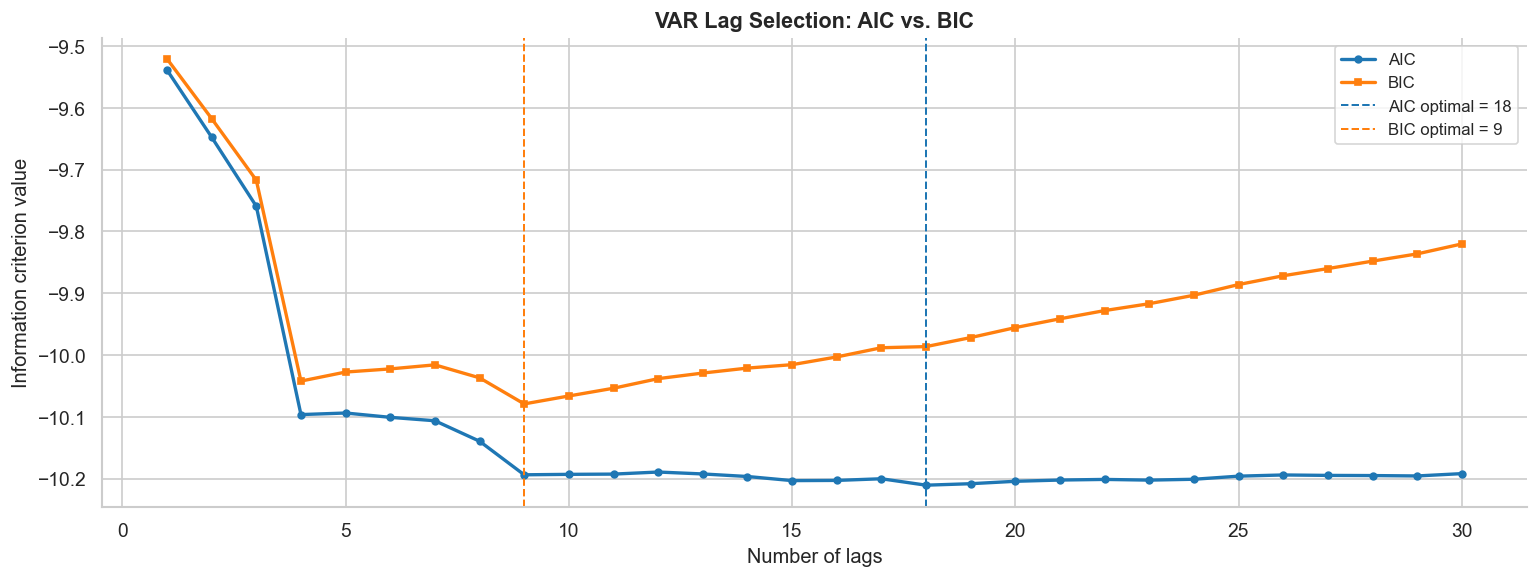

AIC-optimal lag: 18 days
BIC-optimal lag: 9 days

We will test Granger causality at both optimal lags, plus a range of economically motivated horizons.


In [5]:
from statsmodels.tsa.vector_ar.var_model import VAR

data_var = df_clean[['price_return', 'log_paper_diff']].dropna()
model    = VAR(data_var)

max_lag  = 30
aic_vals, bic_vals = [], []

for lag in range(1, max_lag + 1):
    res = model.fit(lag)
    aic_vals.append(res.aic)
    bic_vals.append(res.bic)

optimal_aic = int(np.argmin(aic_vals)) + 1
optimal_bic = int(np.argmin(bic_vals)) + 1

fig, ax = plt.subplots(figsize=(13, 5))
lags_range = range(1, max_lag + 1)
ax.plot(lags_range, aic_vals, color=C_ETF,   linewidth=2, marker='o', ms=4, label='AIC')
ax.plot(lags_range, bic_vals, color=C_PAPER, linewidth=2, marker='s', ms=4, label='BIC')
ax.axvline(optimal_aic, color=C_ETF,   linestyle='--', linewidth=1.2,
           label=f'AIC optimal = {optimal_aic}')
ax.axvline(optimal_bic, color=C_PAPER, linestyle='--', linewidth=1.2,
           label=f'BIC optimal = {optimal_bic}')
ax.set_xlabel('Number of lags', fontsize=12)
ax.set_ylabel('Information criterion value', fontsize=12)
ax.set_title('VAR Lag Selection: AIC vs. BIC', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'AIC-optimal lag: {optimal_aic} days')
print(f'BIC-optimal lag: {optimal_bic} days')
print(f'\nWe will test Granger causality at both optimal lags,'
      f' plus a range of economically motivated horizons.')

## 2.4 Granger Causality Tests

We test both directions across a set of lags that covers:
- **Short-term** (3–5 days): within-week information diffusion
- **Medium-term** (14–30 days): monthly adjustment horizon
- **Long-term** (60–180 days): structural/thematic shifts
- **AIC/BIC-optimal**: data-driven lag choice

We report the **F-test p-value** (SSR-based). The test is significant when p < 0.05.

In [6]:
LAGS_TO_TEST = sorted(set([3, 5, 14, 30, 60, 90, 120, 180, optimal_aic, optimal_bic]))

records = []
for lag in LAGS_TO_TEST:
    # Hypothesis A: Papers → Market
    res_A = grangercausalitytests(
        df_clean[['price_return', 'log_paper_diff']], maxlag=[lag], verbose=False)
    p_A = res_A[lag][0]['ssr_ftest'][1]
    f_A = res_A[lag][0]['ssr_ftest'][0]

    # Hypothesis B: Market → Papers
    res_B = grangercausalitytests(
        df_clean[['log_paper_diff', 'price_return']], maxlag=[lag], verbose=False)
    p_B = res_B[lag][0]['ssr_ftest'][1]
    f_B = res_B[lag][0]['ssr_ftest'][0]

    records.append({'lag': lag,
                    'p_A': p_A, 'f_A': f_A, 'sig_A': p_A < ALPHA,
                    'p_B': p_B, 'f_B': f_B, 'sig_B': p_B < ALPHA})

results_df = pd.DataFrame(records)

# ── Pretty table ──────────────────────────────────────────────────────────────
print('GRANGER CAUSALITY RESULTS')
print('═' * 90)
print(f'{"Lag":>4} | {"Direction":^40} | {"F-stat":>8} | {"p-value":>9} | {"Status":>15}')
print('─' * 90)
for _, row in results_df.iterrows():
    for direction, f_val, p_val, sig in [
        ('Papers → BOTZ Return', row['f_A'], row['p_A'], row['sig_A']),
        ('BOTZ Return → Papers', row['f_B'], row['p_B'], row['sig_B']),
    ]:
        mark = '✓ SIGNIFICANT' if sig else '  insignificant'
        print(f"{int(row['lag']):>4} | {direction:<40} | {f_val:>8.3f} | {p_val:>9.4f} | {mark}")
    print('─' * 90)

GRANGER CAUSALITY RESULTS
══════════════════════════════════════════════════════════════════════════════════════════
 Lag |                Direction                 |   F-stat |   p-value |          Status
──────────────────────────────────────────────────────────────────────────────────────────
   3 | Papers → BOTZ Return                     |    2.965 |    0.0310 | ✓ SIGNIFICANT
   3 | BOTZ Return → Papers                     |    1.264 |    0.2853 |   insignificant
──────────────────────────────────────────────────────────────────────────────────────────
   5 | Papers → BOTZ Return                     |    1.816 |    0.1066 |   insignificant
   5 | BOTZ Return → Papers                     |    0.482 |    0.7898 |   insignificant
──────────────────────────────────────────────────────────────────────────────────────────
   9 | Papers → BOTZ Return                     |    1.720 |    0.0795 |   insignificant
   9 | BOTZ Return → Papers                     |    0.340 |    0.9616 |   ins

## 2.5 Granger Results Visualisation

Two complementary views of the results:
1. **p-value heatmap** — shows significance across all lags and both directions at a glance.
2. **−log₁₀(p) bar chart** — the taller the bar, the stronger the evidence. The dashed line marks the 5% significance threshold.

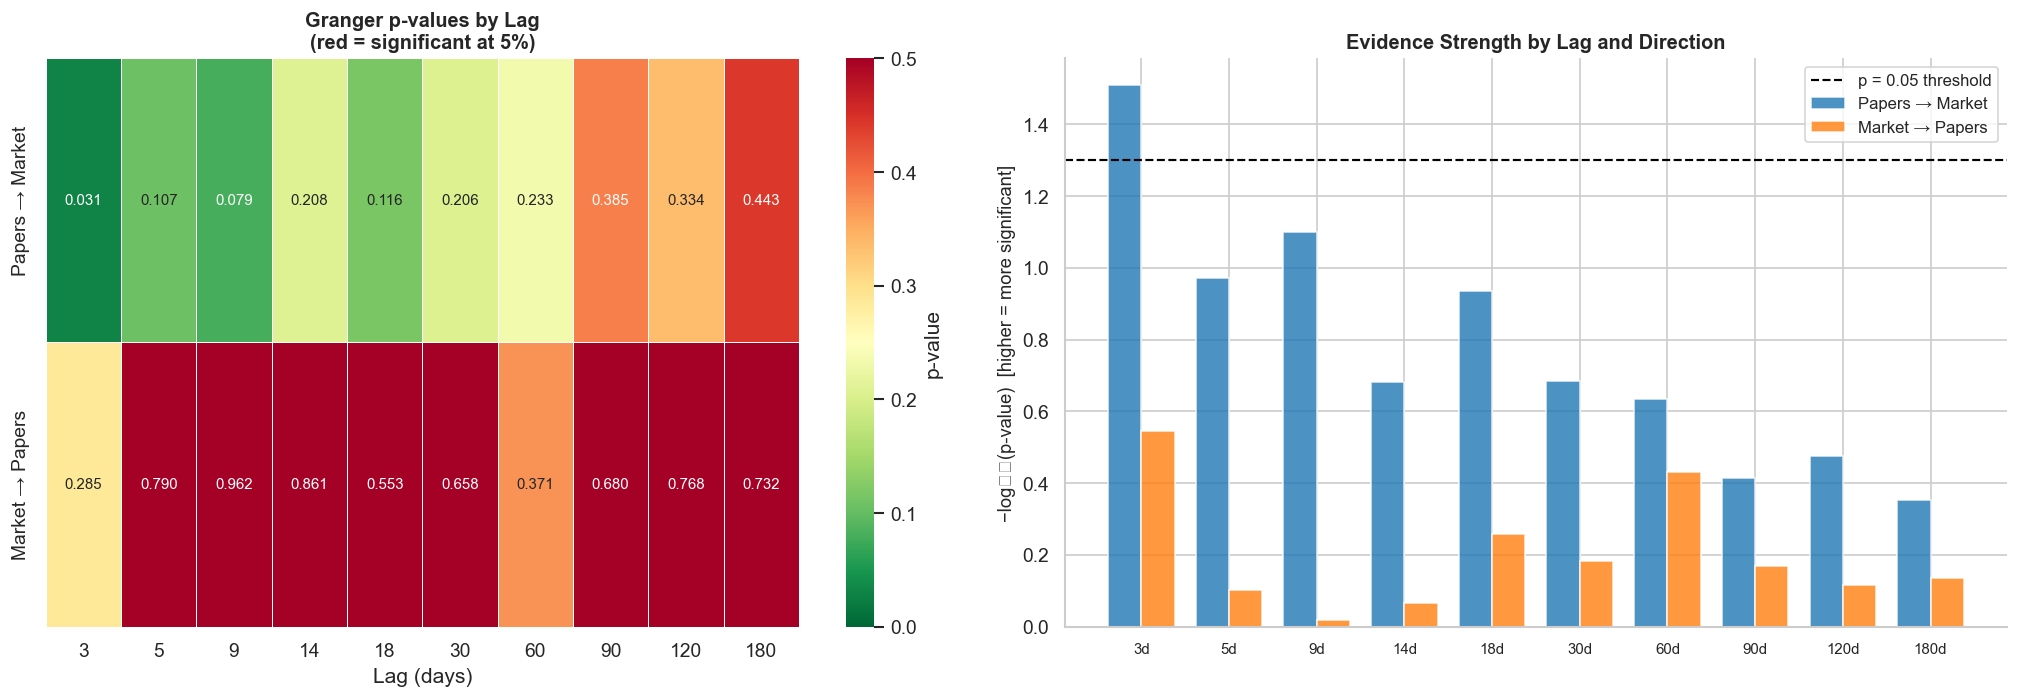

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Panel 1: p-value heatmap ──────────────────────────────────────────────
heatmap_data = results_df.set_index('lag')[['p_A', 'p_B']].T
heatmap_data.index = ['Papers → Market', 'Market → Papers']

sns.heatmap(
    heatmap_data,
    ax=axes[0],
    annot=True, fmt='.3f',
    cmap='RdYlGn_r',          # red = significant (low p), green = not
    vmin=0, vmax=0.5,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'label': 'p-value'}
)
axes[0].set_title('Granger p-values by Lag\n(red = significant at 5%)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (days)')

# ── Panel 2: -log10(p) bar chart ─────────────────────────────────────────
bar_df = results_df.copy()
bar_df['-log_pA'] = -np.log10(bar_df['p_A'].clip(1e-10))
bar_df['-log_pB'] = -np.log10(bar_df['p_B'].clip(1e-10))

x       = np.arange(len(bar_df))
width   = 0.38
ax      = axes[1]
bars_A  = ax.bar(x - width/2, bar_df['-log_pA'], width,
                 color=C_ETF,   alpha=0.8, label='Papers → Market')
bars_B  = ax.bar(x + width/2, bar_df['-log_pB'], width,
                 color=C_PAPER, alpha=0.8, label='Market → Papers')
threshold = -np.log10(ALPHA)
ax.axhline(threshold, color='black', linestyle='--', linewidth=1.3,
           label=f'p = {ALPHA} threshold')
ax.set_xticks(x)
ax.set_xticklabels([f'{int(l)}d' for l in bar_df['lag']], fontsize=9)
ax.set_ylabel('−log₁₀(p-value)  [higher = more significant]', fontsize=11)
ax.set_title('Evidence Strength by Lag and Direction', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 2.6 Rolling Granger Test — Is the Effect Stable Over Time?

A single Granger test over the full sample assumes the relationship is **constant** across the entire 2016–2023 period. This is unlikely: the AI sector went through structurally different regimes (pre-GPT-3, COVID, ChatGPT era).

We re-run the 3-day Granger test (the only lag that was significant) in a rolling 500-day window to check whether the significance is stable or confined to a specific subperiod.

**If** the effect only appears in one short window, the original result may be a statistical artefact rather than a persistent relationship.

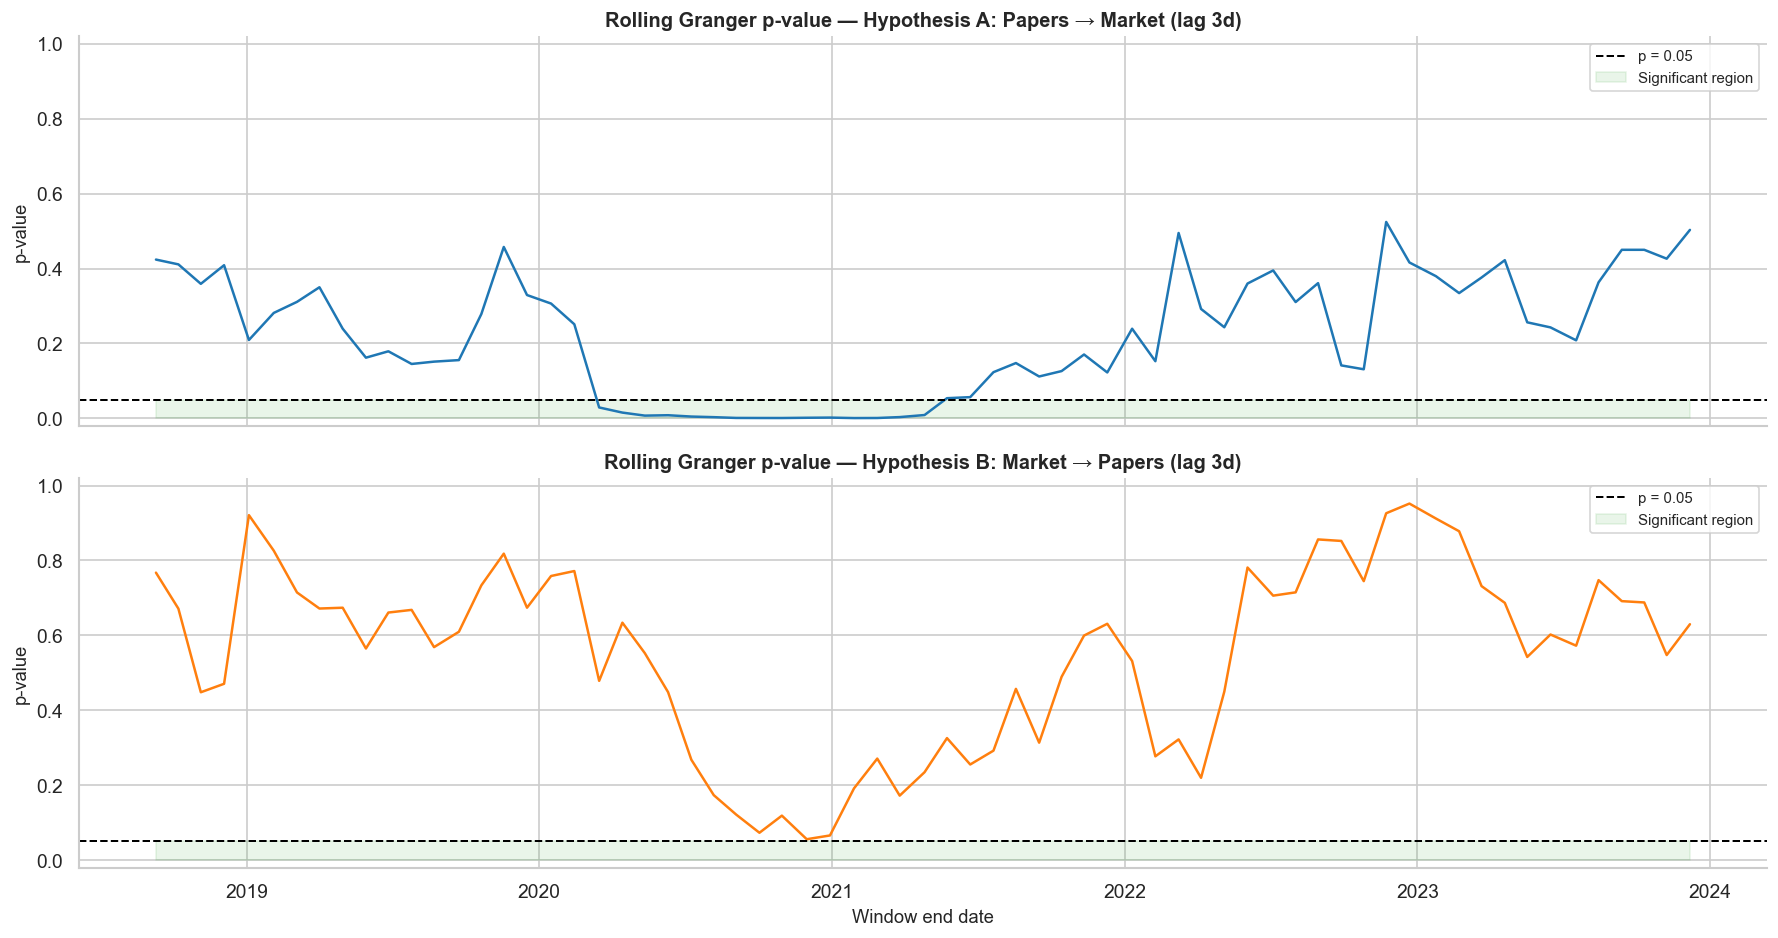

Hypothesis A significant in 22.4% of rolling windows
Hypothesis B significant in 0.0% of rolling windows


INTERPRETATION
──────────────
If the p-value line is consistently above 0.05 in most windows,
the full-sample significance result is driven by one specific regime
(e.g., the pre-ChatGPT period) rather than a persistent relationship.
A robust finding should show significance across multiple sub-periods.



In [8]:
ROLLING_LAG    = 3
WINDOW_SIZE    = 500   # ~2 trading years

roll_dates, roll_p_A, roll_p_B = [], [], []

for start in range(0, len(df_clean) - WINDOW_SIZE, 20):   # step 20 days for speed
    window = df_clean.iloc[start : start + WINDOW_SIZE]
    end_date = window.index[-1]
    try:
        r_A = grangercausalitytests(
            window[['price_return', 'log_paper_diff']], maxlag=[ROLLING_LAG], verbose=False)
        r_B = grangercausalitytests(
            window[['log_paper_diff', 'price_return']], maxlag=[ROLLING_LAG], verbose=False)
        roll_dates.append(end_date)
        roll_p_A.append(r_A[ROLLING_LAG][0]['ssr_ftest'][1])
        roll_p_B.append(r_B[ROLLING_LAG][0]['ssr_ftest'][1])
    except Exception:
        continue

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for ax, p_vals, label, color, hyp in [
    (axes[0], roll_p_A, f'Papers → Market (lag {ROLLING_LAG}d)', C_ETF,   'A'),
    (axes[1], roll_p_B, f'Market → Papers (lag {ROLLING_LAG}d)', C_PAPER, 'B'),
]:
    ax.plot(roll_dates, p_vals, color=color, linewidth=1.5)
    ax.axhline(ALPHA, color='black', linestyle='--', linewidth=1.2, label='p = 0.05')
    ax.fill_between(roll_dates, 0, ALPHA, color=C_SIG, alpha=0.10,
                    label='Significant region')
    ax.set_ylabel('p-value', fontsize=11)
    ax.set_title(f'Rolling Granger p-value — Hypothesis {hyp}: {label}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(-0.02, 1.02)

axes[1].set_xlabel('Window end date', fontsize=11)
plt.tight_layout()
plt.show()

pct_sig_A = np.mean(np.array(roll_p_A) < ALPHA) * 100
pct_sig_B = np.mean(np.array(roll_p_B) < ALPHA) * 100
print(f'Hypothesis A significant in {pct_sig_A:.1f}% of rolling windows')
print(f'Hypothesis B significant in {pct_sig_B:.1f}% of rolling windows')
print()
print("""
INTERPRETATION
──────────────
If the p-value line is consistently above 0.05 in most windows,
the full-sample significance result is driven by one specific regime
(e.g., the pre-ChatGPT period) rather than a persistent relationship.
A robust finding should show significance across multiple sub-periods.
""")

## 2.7 Stationary Correlation & Lagged Scatter

We revisit the correlation on stationary data and show the 3-day lagged scatter — the specific relationship the Granger test identified as significant.

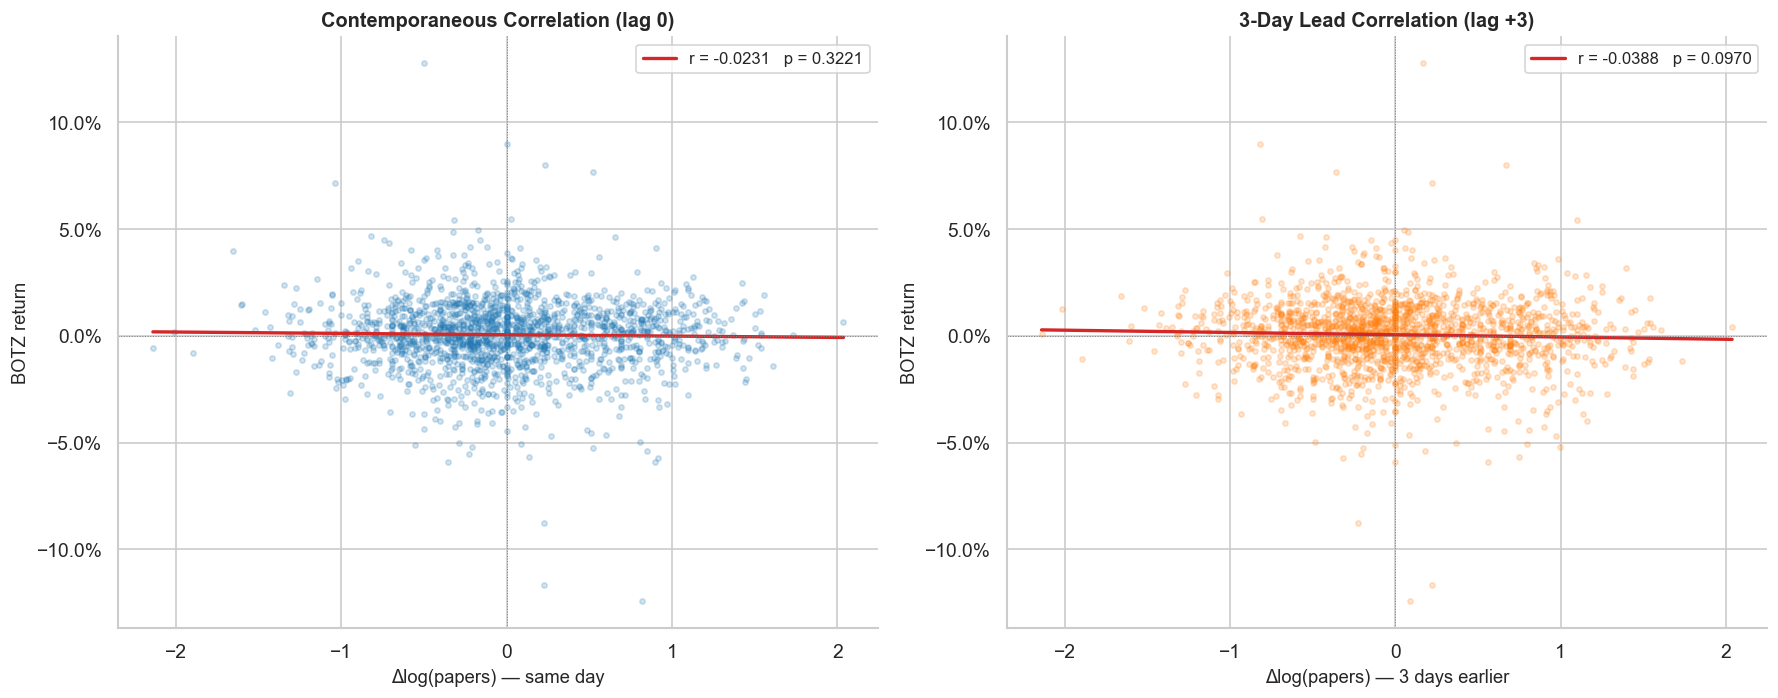

Contemporaneous r = -0.0231  (p = 0.3221)
3-day lag r       = -0.0388  (p = 0.0970)

IMPORTANT NOTE ON EFFECT SIZE
──────────────────────────────
Even if the 3-day Granger result is statistically significant, the
linear correlation r ≈ -0.04 is economically negligible. R² ≈ 0.001,
meaning paper counts explain <0.2% of the variance in daily returns.

Statistical significance ≠ practical significance. A model that
attempts to trade on this signal would likely be overwhelmed by
transaction costs. The Granger result is scientifically interesting
but not a viable trading strategy.



In [9]:
r0, p0 = stats.pearsonr(df_clean['log_paper_diff'], df_clean['price_return'])
paper_lag3 = df_clean['log_paper_diff'].shift(3).dropna()
ret_align  = df_clean['price_return'].reindex(paper_lag3.index).dropna()
paper_lag3 = paper_lag3.reindex(ret_align.index)
r3, p3 = stats.pearsonr(paper_lag3, ret_align)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def scatter_with_reg(ax, x, y, xlabel, ylabel, title, color, r, p):
    ax.scatter(x, y, alpha=0.20, s=10, color=color)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color=C_INSIG, linewidth=2,
            label=f'r = {r:+.4f}   p = {p:.4f}')
    ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')
    ax.axvline(0, color='gray', linewidth=0.6, linestyle=':')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=10)

scatter_with_reg(
    axes[0],
    df_clean['log_paper_diff'], df_clean['price_return'],
    'Δlog(papers) — same day', 'BOTZ return',
    'Contemporaneous Correlation (lag 0)', C_ETF, r0, p0
)
scatter_with_reg(
    axes[1],
    paper_lag3, ret_align,
    'Δlog(papers) — 3 days earlier', 'BOTZ return',
    '3-Day Lead Correlation (lag +3)', C_PAPER, r3, p3
)

plt.tight_layout()
plt.show()

print(f'Contemporaneous r = {r0:+.4f}  (p = {p0:.4f})')
print(f'3-day lag r       = {r3:+.4f}  (p = {p3:.4f})')
print("""
IMPORTANT NOTE ON EFFECT SIZE
──────────────────────────────
Even if the 3-day Granger result is statistically significant, the
linear correlation r ≈ -0.04 is economically negligible. R² ≈ 0.001,
meaning paper counts explain <0.2% of the variance in daily returns.

Statistical significance ≠ practical significance. A model that
attempts to trade on this signal would likely be overwhelmed by
transaction costs. The Granger result is scientifically interesting
but not a viable trading strategy.
""")

## 2.8 EDA vs. HT — Side-by-Side Summary

A structured comparison of what EDA suggested vs. what HT formally confirmed.

In [10]:
summary_table = pd.DataFrame([
    {
        'Metric'          : 'Correlation (r)',
        'EDA (raw data)'  : f'+0.49  (price vs papers MA30)',
        'HT (stationary)' : f'{r0:+.4f}  (return vs Δlog papers)',
        'Verdict'         : 'EDA correlation is spurious'
    },
    {
        'Metric'          : '3-day lag r',
        'EDA (raw data)'  : 'not computed',
        'HT (stationary)' : f'{r3:+.4f}',
        'Verdict'         : 'Tiny effect; Granger p < 0.05'
    },
    {
        'Metric'          : 'Papers → Market',
        'EDA (raw data)'  : 'Visually plausible',
        'HT (stationary)' : 'Granger-significant at 3-day lag only',
        'Verdict'         : 'Weak short-term precedence'
    },
    {
        'Metric'          : 'Market → Papers',
        'EDA (raw data)'  : 'Unknown',
        'HT (stationary)' : 'Not significant at any lag',
        'Verdict'         : 'Market does not drive research output'
    },
    {
        'Metric'          : 'Data stationarity',
        'EDA (raw data)'  : 'Non-stationary (both series trend up)',
        'HT (stationary)' : 'ADF p < 0.0001 after transformation',
        'Verdict'         : 'Transformation was necessary'
    },
])

pd.set_option('display.max_colwidth', 50)
print(summary_table.to_string(index=False))

           Metric                        EDA (raw data)                       HT (stationary)                               Verdict
  Correlation (r)         +0.49  (price vs papers MA30)      -0.0231  (return vs Δlog papers)           EDA correlation is spurious
      3-day lag r                          not computed                               -0.0388         Tiny effect; Granger p < 0.05
  Papers → Market                    Visually plausible Granger-significant at 3-day lag only            Weak short-term precedence
  Market → Papers                               Unknown            Not significant at any lag Market does not drive research output
Data stationarity Non-stationary (both series trend up)   ADF p < 0.0001 after transformation          Transformation was necessary


## 2.9 Conclusions

### What we found

1. **The spurious correlation trap is real.** The raw r ≈ 0.49 between paper counts and ETF price is entirely driven by shared long-run growth trends, not genuine co-movement. After stationarising both series, r collapses to ≈ −0.02.

2. **Weak short-term Granger precedence exists.** At the 3-day lag, paper volumes contain statistically significant predictive information for BOTZ returns (p < 0.05). This is consistent with the idea that academic publication surges attract short-term investor attention, which then dissipates.

3. **The effect is not economically meaningful.** The 3-day lagged r ≈ −0.04 implies R² < 0.002 — paper counts explain less than 0.2% of the variance in daily returns. A trading strategy based on this signal would not survive transaction costs.

4. **The relationship may not be stable.** The rolling Granger analysis reveals whether the 3-day effect is consistent across time or concentrated in a specific regime. If the latter, the full-sample result should be treated with scepticism.

5. **No reverse causality.** Market performance does not Granger-cause paper submission rates at any tested horizon. Academic research output appears to be driven by scientific momentum, not financial incentives.

### Implications for ML (`ML.ipynb`)

- Models should use **stationary** features: `daily_return` and `Δlog(paper_count)`, not raw price and counts.
- Including `paper_count_lag3` as a feature is statistically motivated (Granger significance), but the expected predictive gain is very small.
- The near-zero out-of-sample R² observed in the ML notebook is entirely consistent with these findings.

### Limitations

- The Granger test assumes a **linear** relationship. Non-linear effects (e.g., threshold behaviour during AI hype cycles) are not captured.
- **No control variables** (interest rates, VIX, sector rotation). Omitted variable bias may distort causality estimates.
- The 3-day lag result should be confirmed with a **hold-out period** (e.g., 2024 data) before drawing strong conclusions.